# VAE Final Baseline Comparison

Notebook-first final comparison for the VAE section of the project.

This compares three attack-profile sources:

1. **P01-P60 fixed library**: the original small scaffold/profile library we started from.
2. **Direct curated v4 synthetic**: hit-threat records sampled directly from the curated tactical generator output.
3. **Mixed 70/30 VAE candidates**: hit-threat candidates generated by the final mixed curated/random VAE candidate-pool workflow.

The goal is to separate two questions:

- Did the new pipeline improve beyond the original `P01-P60` fixed profiles?
- Does the VAE add useful GenAI candidate generation beyond directly using the synthetic generator?

The Monte Carlo section reuses `experiments.evaluate_attack_candidate_pool`, so this notebook evaluates candidates through the same moving, jittered, evasive convoy simulation used elsewhere in the project.


## Imports

In [1]:
from __future__ import annotations

from collections import Counter
import copy
import json
import math
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "convoy_sim").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from convoy_sim.attack_profiles import DEFAULT_ATTACK_PROFILE_LIBRARY
from convoy_sim.profile_generation_viz import FIXED_X_LIMITS, apply_limits, combined_limits, simple_ship_polygons, style_ax
from convoy_sim.target_zones import convoy_frame_and_envelope
from experiments.evaluate_attack_candidate_pool import evaluate_candidate_pool
from scenarios.convoy_profiles import get_convoy_layout_profile

PROJECT_ROOT


PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project')

## Config

In [2]:
CONVOY_PROFILE = "convoy_layout_1"

# Existing data/candidate sources.
CURATED_V4_TRAIN_PATH = PROJECT_ROOT / "data/attack_profiles/synthetic/train_random_tactical_v4_45k.jsonl"
MIXED_VAE_CANDIDATE_PATH = PROJECT_ROOT / "data/attack_profiles/vae_candidates/mixed_curated70_random30_hit_candidates.jsonl"

# Notebook-generated comparison candidate pools.
OUTPUT_DIR = PROJECT_ROOT / "results" / "diag" / "vae_final_baseline_comparison"
POOL_DIR = OUTPUT_DIR / "candidate_pools"
P01_P60_CANDIDATE_PATH = POOL_DIR / "p01_p60_candidates.jsonl"
CURATED_V4_DIRECT_CANDIDATE_PATH = POOL_DIR / "curated_v4_direct_hit_candidates.jsonl"

# Direct curated-v4 baseline sampling. This keeps the direct-synthetic baseline matched to the VAE pool size.
DIRECT_CURATED_KEEP_COUNT = 1_000
DIRECT_CURATED_SAMPLE_SEED = 1945
ACCEPTED_OUTCOME = "credible_hit_threat"
MIN_CLEARANCE_M = 250.0

# Monte Carlo comparison. 
RUN_MONTE_CARLO_EVALUATION = True
MAX_EVAL_PROFILES_BY_SOURCE = {
    "p01_p60": None,              # evaluate all 60 original profiles
    "curated_v4_direct": None,     #Run all 1,000 profiles
    "mixed_vae": None,
}
TOP_K = 25
EVAL_SEEDS = [1942, 1943, 1944]
N_TRIALS_PER_SEED = 10
EVAL_T_MAX = 400.0
OBJECTIVE_CFG = {"preset": "balanced_default"}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
POOL_DIR.mkdir(parents=True, exist_ok=True)


## Helpers

In [16]:
def load_jsonl(path: Path) -> list[dict[str, Any]]:
    records: list[dict[str, Any]] = []
    with (PROJECT_ROOT / path if not path.is_absolute() else path).open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSON in {path} line {line_number}") from exc
    return records


def write_jsonl(path: Path, records: list[dict[str, Any]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record, sort_keys=True) + "\n")


def write_csv(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


def outcome_label(record: dict[str, Any]) -> str:
    audit = dict(record.get("audit", {}))
    outcome = dict(record.get("outcome", {}))
    intent = dict(record.get("intent", {}))
    gate = dict(audit.get("outcome_gate", {}))
    return str(
        outcome.get(
            "actual_outcome_label",
            audit.get("actual_outcome_label", gate.get("actual_outcome_label", intent.get("intended_label", ""))),
        )
    )


def clearance_m(record: dict[str, Any]) -> float:
    audit = dict(record.get("audit", {}))
    intent = dict(record.get("intent", {}))
    for value in (audit.get("clearance_m"), intent.get("nearest_ship_clearance_m")):
        if value is not None and value != "":
            try:
                parsed = float(value)
            except (TypeError, ValueError):
                continue
            if np.isfinite(parsed):
                return parsed
    return float("nan")


def normalize_spawn_region(region: str, *, inside: bool = False) -> str:
    if inside:
        return "inside_convoy_envelope"
    text = str(region).strip().lower()
    if not text:
        return "unknown"
    if text == "inside" or "inside" in text:
        return "inside_convoy_envelope"
    if text.startswith("ahead") or "ahead" in text or "forward" in text:
        return "ahead"
    if text.startswith("astern") or "astern" in text or "aft" in text or "trailing" in text:
        return "astern"
    if text.startswith("port") or "port" in text:
        return "port"
    if text.startswith("starboard") or "starboard" in text:
        return "starboard"
    return text.replace("_vae", "")


def derived_spawn_region(local_xy: np.ndarray, envelope) -> tuple[str, str, bool]:
    inside = bool(envelope.min_x <= float(local_xy[0]) <= envelope.max_x and envelope.min_y <= float(local_xy[1]) <= envelope.max_y)
    if inside:
        return "inside_convoy_envelope", "inside", True
    distances = {
        "ahead": float(local_xy[0] - envelope.max_x),
        "astern": float(envelope.min_x - local_xy[0]),
        "port": float(local_xy[1] - envelope.max_y),
        "starboard": float(envelope.min_y - local_xy[1]),
    }
    region = max(distances.items(), key=lambda item: item[1])[0]
    return region, region, False


def nearest_ship_clearance_world(u_pos: list[float] | tuple[float, float], ships) -> float:
    u = np.asarray(u_pos, dtype=float)
    ship_xy = np.asarray([np.asarray(ship.position, dtype=float) for ship in ships], dtype=float)
    return float(np.min(np.linalg.norm(ship_xy - u, axis=1)))


def build_p01_p60_candidate_records(ships, frame, envelope) -> list[dict[str, Any]]:
    records: list[dict[str, Any]] = []
    for profile in DEFAULT_ATTACK_PROFILE_LIBRARY.profiles:
        payload = profile.to_dict()
        u_pos = [float(payload["u_pos"][0]), float(payload["u_pos"][1])]
        local = frame.world_to_local(u_pos)
        region, approach_side, inside = derived_spawn_region(local, envelope)
        clear = nearest_ship_clearance_world(u_pos, ships)
        records.append(
            {
                "profile": payload,
                "audit": {
                    "profile_id": str(payload["profile_id"]),
                    "name": str(payload.get("name", "")),
                    "suggested_label": "p01_p60_fixed_library",
                    "spawn_region": region,
                    "approach_side": approach_side,
                    "inside_convoy_envelope": inside,
                    "clearance_m": float(clear),
                },
                "intent": {
                    "target_zone_kind": "p01_p60_fixed_library",
                    "spawn_local": [float(local[0]), float(local[1])],
                    "spawn_region": region,
                    "approach_side": approach_side,
                    "approach_lane": f"{region}:fixed_library",
                    "inside_convoy_envelope": inside,
                    "nearest_ship_clearance_m": float(clear),
                },
                "outcome": {},
                "generator_meta": {
                    "mode": "p01_p60_fixed_library",
                    "source": "DEFAULT_ATTACK_PROFILE_LIBRARY",
                    "convoy_profile": CONVOY_PROFILE,
                    "record_role": "original_baseline",
                },
            }
        )
    return records


def select_direct_curated_v4_records(records: list[dict[str, Any]], *, keep_count: int, seed: int) -> list[dict[str, Any]]:
    eligible = [
        record
        for record in records
        if outcome_label(record) == ACCEPTED_OUTCOME and clearance_m(record) >= float(MIN_CLEARANCE_M)
    ]
    if len(eligible) < keep_count:
        raise ValueError(f"Only {len(eligible)} eligible direct curated-v4 records for requested keep_count={keep_count}")
    rng = np.random.default_rng(int(seed))
    indices = rng.choice(len(eligible), size=int(keep_count), replace=False)
    selected: list[dict[str, Any]] = []
    for rank, idx in enumerate(indices, start=1):
        record = copy.deepcopy(eligible[int(idx)])
        record.setdefault("generator_meta", {})
        record["generator_meta"]["comparison_source"] = "curated_v4_direct"
        record["generator_meta"]["comparison_sample_rank"] = int(rank)
        selected.append(record)
    return selected


def candidate_records_to_df(records: list[dict[str, Any]], *, source_id: str, source_label: str) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for record in records:
        profile = dict(record.get("profile", {}))
        audit = dict(record.get("audit", {}))
        intent = dict(record.get("intent", {}))
        outcome = dict(record.get("outcome", {}))
        u_pos = list(profile.get("u_pos", [np.nan, np.nan]))
        inside = bool(intent.get("inside_convoy_envelope", audit.get("inside_convoy_envelope", False)))
        raw_region = str(intent.get("spawn_region", audit.get("spawn_region", "")))
        n_hits_raw = outcome.get("n_hits", audit.get("n_hits"))
        unique_hits_raw = outcome.get("unique_ships_hit", audit.get("unique_ships_hit"))
        rows.append(
            {
                "source_id": source_id,
                "source_label": source_label,
                "profile_id": str(profile.get("profile_id", "")),
                "u_pos": [float(u_pos[0]), float(u_pos[1])],
                "u_pos_x": float(u_pos[0]),
                "u_pos_y": float(u_pos[1]),
                "raw_spawn_region": raw_region,
                "spawn_region": normalize_spawn_region(raw_region, inside=inside),
                "approach_side": str(intent.get("approach_side", audit.get("approach_side", ""))),
                "inside_convoy_envelope": inside,
                "suggested_label": str(audit.get("suggested_label", "")),
                "actual_outcome_label": outcome_label(record),
                "clearance_m": clearance_m(record),
                "n_hits": np.nan if n_hits_raw in (None, "") else int(n_hits_raw),
                "unique_ships_hit": np.nan if unique_hits_raw in (None, "") else int(unique_hits_raw),
                "closest_any_ship_distance_m": float(outcome.get("closest_any_ship_distance_m", audit.get("closest_any_ship_distance_m", np.nan)) or np.nan),
                "source_mode": str(dict(record.get("generator_meta", {})).get("mode", "")),
            }
        )
    return pd.DataFrame(rows)


def occupied_bins(points: np.ndarray, *, bin_size_m: float) -> int:
    if len(points) == 0:
        return 0
    bins = np.floor(np.asarray(points, dtype=float) / float(bin_size_m)).astype(int)
    return int(len({tuple(row) for row in bins.tolist()}))


def source_summary(df: pd.DataFrame) -> dict[str, Any]:
    xy = df[["u_pos_x", "u_pos_y"]].to_numpy(dtype=float) if len(df) else np.empty((0, 2))
    label_counts = df["actual_outcome_label"].value_counts(dropna=False).to_dict() if len(df) else {}
    return {
        "source_id": str(df["source_id"].iloc[0]) if len(df) else "",
        "source_label": str(df["source_label"].iloc[0]) if len(df) else "",
        "profile_count": int(len(df)),
        "hit_threat_count": int(label_counts.get("credible_hit_threat", 0)),
        "hit_threat_rate": float(label_counts.get("credible_hit_threat", 0)) / max(int(len(df)), 1),
        "inside_convoy_envelope_rate": float(df["inside_convoy_envelope"].mean()) if len(df) else np.nan,
        "mean_clearance_m": float(df["clearance_m"].mean()) if len(df) else np.nan,
        "median_clearance_m": float(df["clearance_m"].median()) if len(df) else np.nan,
        "min_clearance_m": float(df["clearance_m"].min()) if len(df) else np.nan,
        "mean_hits_source_audit": float(df["n_hits"].mean(skipna=True)) if df["n_hits"].notna().any() else np.nan,
        "mean_unique_ships_hit_source_audit": float(df["unique_ships_hit"].mean(skipna=True)) if df["unique_ships_hit"].notna().any() else np.nan,
        "x_min_m": float(np.min(xy[:, 0])) if len(xy) else np.nan,
        "x_max_m": float(np.max(xy[:, 0])) if len(xy) else np.nan,
        "y_min_m": float(np.min(xy[:, 1])) if len(xy) else np.nan,
        "y_max_m": float(np.max(xy[:, 1])) if len(xy) else np.nan,
        "occupied_250m_bins": occupied_bins(xy, bin_size_m=250.0),
        "occupied_500m_bins": occupied_bins(xy, bin_size_m=500.0),
    }


def plot_source_spawns(ax, ships, df: pd.DataFrame, *, title: str, limits) -> None:
    style_ax(ax, title)
    simple_ship_polygons(ax, ships)
    if len(df):
        xy = df[["u_pos_x", "u_pos_y"]].to_numpy(dtype=float)
        ax.scatter(xy[:, 0], xy[:, 1], c="#111111", s=8, alpha=0.45, zorder=2, label="U-boat spawn")
        # ax.legend(frameon=False, loc="upper right")
    apply_limits(ax, limits, fixed_x_limits=FIXED_X_LIMITS)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")


def plot_region_spawns(ax, ships, df: pd.DataFrame, *, title: str, limits, color_map: dict[str, Any]) -> None:
    style_ax(ax, title)
    simple_ship_polygons(ax, ships)
    for region, group in df.groupby("spawn_region"):
        xy = group[["u_pos_x", "u_pos_y"]].to_numpy(dtype=float)
        ax.scatter(xy[:, 0], xy[:, 1], c=[color_map.get(region, "#111111")], s=5, alpha=0.75, zorder=2, label=region)
    apply_limits(ax, limits, fixed_x_limits=FIXED_X_LIMITS)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")


## Build Comparison Candidate Pools

The P01-P60 and direct curated-v4 pools are written into `results/diag/vae_final_baseline_comparison/candidate_pools/` so the same evaluator can consume all three sources.

The VAE pool is **not** raw synthetic training data. It is the final mixed 70/30 VAE-generated candidate JSONL already produced by the VAE candidate-pool workflow.


In [11]:
ships = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
frame, envelope, _local_positions = convoy_frame_and_envelope(ships)

p01_records = build_p01_p60_candidate_records(ships, frame, envelope)
write_jsonl(P01_P60_CANDIDATE_PATH, p01_records)

curated_raw_records = load_jsonl(CURATED_V4_TRAIN_PATH)
curated_direct_records = select_direct_curated_v4_records(
    curated_raw_records,
    keep_count=int(DIRECT_CURATED_KEEP_COUNT),
    seed=int(DIRECT_CURATED_SAMPLE_SEED),
)
write_jsonl(CURATED_V4_DIRECT_CANDIDATE_PATH, curated_direct_records)

mixed_vae_records = load_jsonl(MIXED_VAE_CANDIDATE_PATH)

source_records = {
    "p01_p60": {
        "label": "P01-P60 Fixed Profile Library",
        "path": P01_P60_CANDIDATE_PATH,
        "records": p01_records,
    },
    "curated_v4_direct": {
        "label": "Curated v4 Synthetic Data",
        "path": CURATED_V4_DIRECT_CANDIDATE_PATH,
        "records": curated_direct_records,
    },
    "mixed_vae": {
        "label": "Mixed 70/30 VAE Generated Candidates",
        "path": MIXED_VAE_CANDIDATE_PATH,
        "records": mixed_vae_records,
    },
}

pd.DataFrame(
    [
        {
            "source_id": source_id,
            "label": cfg["label"],
            "records": len(cfg["records"]),
            "candidate_path": str(cfg["path"]),
        }
        for source_id, cfg in source_records.items()
    ]
)


,source_id,label,records,candidate_path
0,p01_p60,P01-P60 Fixed Profile Library,60,/Users/matthewplambeck/Desktop/Convoy Layout P...
1,curated_v4_direct,Curated v4 Synthetic Data,1000,/Users/matthewplambeck/Desktop/Convoy Layout P...
2,mixed_vae,Mixed 70/30 VAE Generated Candidates,1000,/Users/matthewplambeck/Desktop/Convoy Layout P...


## Source-Level Summary

In [5]:
source_dfs = []
for source_id, cfg in source_records.items():
    source_dfs.append(candidate_records_to_df(cfg["records"], source_id=source_id, source_label=cfg["label"]))

all_candidates_df = pd.concat(source_dfs, ignore_index=True)
source_summary_df = pd.DataFrame([source_summary(df) for df in source_dfs])
region_counts_df = (
    all_candidates_df.groupby(["source_label", "spawn_region"])
    .size()
    .reset_index(name="count")
    .pivot(index="source_label", columns="spawn_region", values="count")
    .fillna(0)
    .astype(int)
    .reset_index()
)
hit_counts_df = (
    all_candidates_df.dropna(subset=["n_hits"])
    .groupby(["source_label", "n_hits"])
    .size()
    .reset_index(name="count")
    .pivot(index="source_label", columns="n_hits", values="count")
    .fillna(0)
    .astype(int)
    .reset_index()
)

write_csv(all_candidates_df, OUTPUT_DIR / "final_baseline_candidate_records_flat.csv")
write_csv(source_summary_df, OUTPUT_DIR / "final_baseline_source_summary.csv")
write_csv(region_counts_df, OUTPUT_DIR / "final_baseline_spawn_region_counts.csv")
write_csv(hit_counts_df, OUTPUT_DIR / "final_baseline_source_hit_counts.csv")

source_summary_df


,source_id,source_label,profile_count,hit_threat_count,hit_threat_rate,inside_convoy_envelope_rate,mean_clearance_m,median_clearance_m,min_clearance_m,mean_hits_source_audit,mean_unique_ships_hit_source_audit,x_min_m,x_max_m,y_min_m,y_max_m,occupied_250m_bins,occupied_500m_bins
0,p01_p60,P01-P60 fixed library,60,0,0.0,0.250,1049.198765,767.983801,244.139714,NaN,NaN,-3200.000000,3600.000000,-3500.000000,3500.000000,48,41
1,curated_v4_direct,Direct curated v4 synthetic,1000,1000,1.0,0.198,1546.088477,1394.634759,284.238963,NaN,NaN,-4860.706206,4913.456185,-7453.672406,7599.466550,689,370
2,mixed_vae,Mixed 70/30 VAE candidates,1000,1000,1.0,0.210,1564.940959,1315.714848,250.456643,3.041,1.896,-4754.330078,5125.385742,-9775.298828,9638.978516,708,410


In [6]:
region_counts_df

spawn_region,source_label,ahead,astern,beam_attack,inside_convoy_envelope,outside_perimeter,port,starboard
0,Direct curated v4 synthetic,215,106,147,198,334,0,0
1,Mixed 70/30 VAE candidates,297,181,0,210,0,154,158
2,P01-P60 fixed library,33,12,0,15,0,0,0


In [7]:
hit_counts_df

n_hits,source_label,1.0,2.0,3.0,4.0
0,Mixed 70/30 VAE candidates,72,221,301,406


## Spawn Geometry Plots

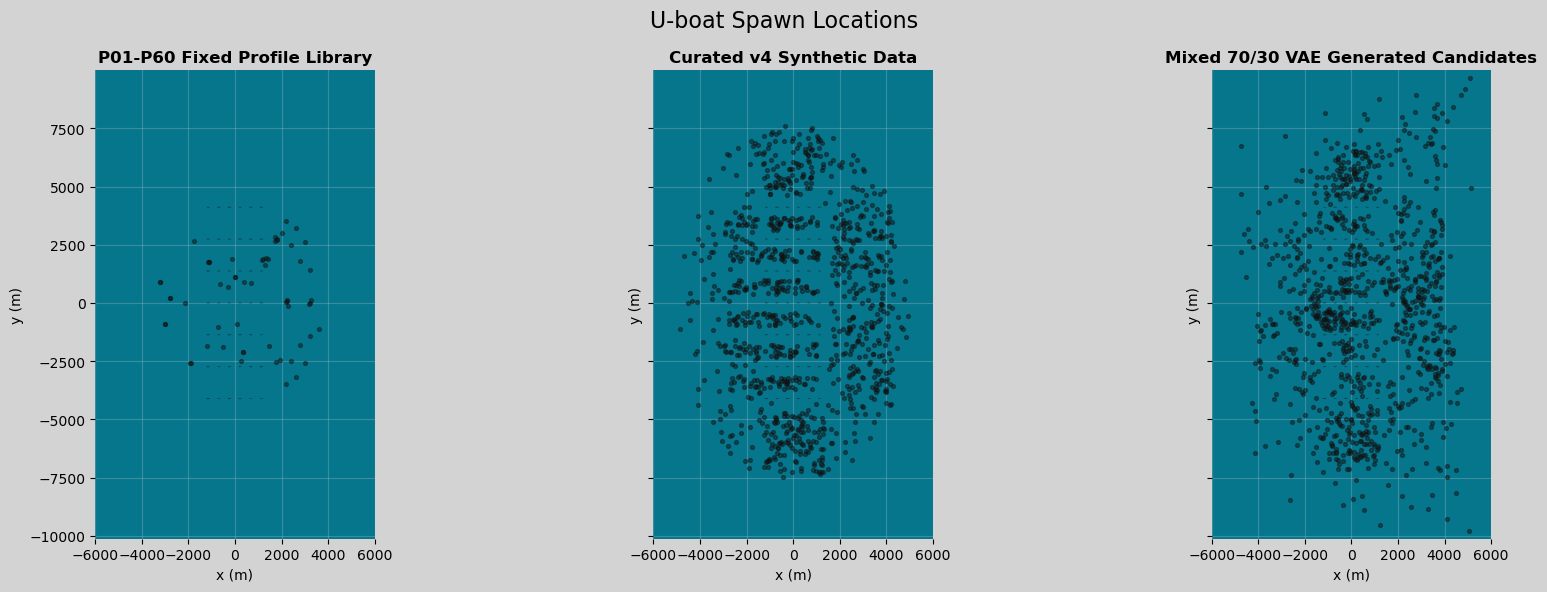

In [17]:
combined_xy = all_candidates_df[["u_pos_x", "u_pos_y"]].to_numpy(dtype=float)
shared_limits = combined_limits(ships, extra_points=combined_xy, pad=350.0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="lightgrey", sharex=True, sharey=True)
for ax, (source_id, cfg) in zip(axes, source_records.items()):
    df = all_candidates_df.loc[all_candidates_df["source_id"] == source_id].copy()
    plot_source_spawns(ax, ships, df, title=cfg["label"], limits=shared_limits)
fig.suptitle("U-boat Spawn Locations", fontsize=16)
plt.tight_layout()
plt.savefig("final_comparison.png")
plt.show()


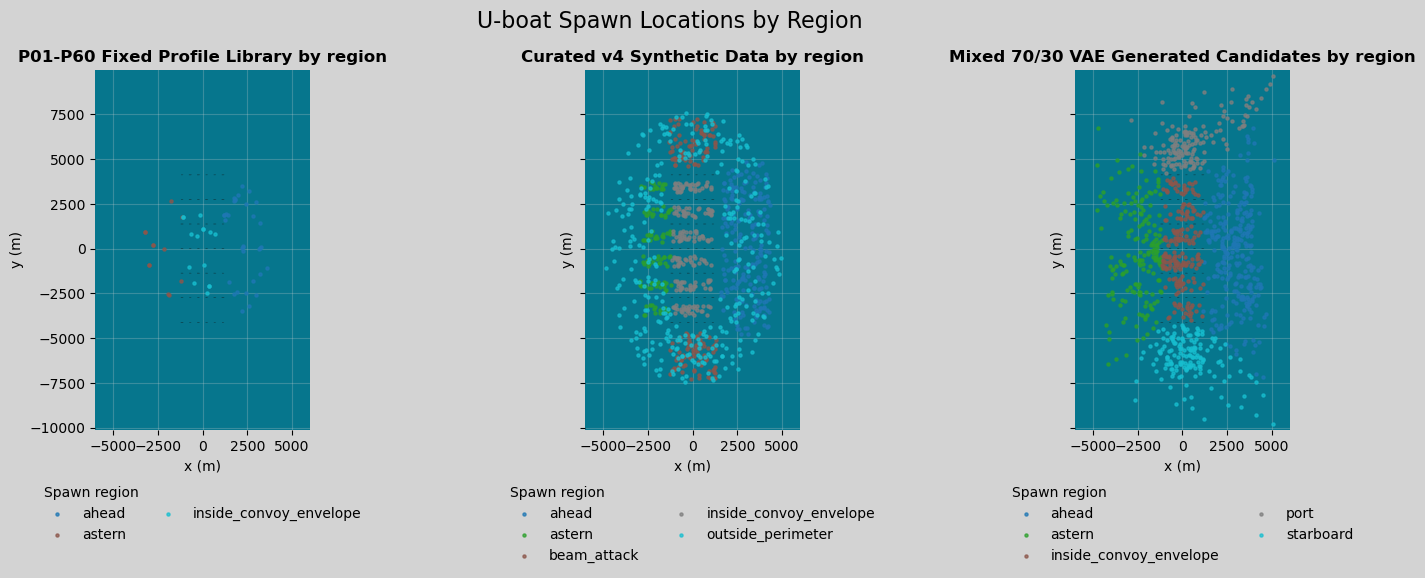

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="lightgrey", sharex=True, sharey=True)
for ax, (source_id, cfg) in zip(axes, source_records.items()):
    df = all_candidates_df.loc[all_candidates_df["source_id"] == source_id].copy()
    color_values = sorted(str(value) for value in df["spawn_region"].dropna().unique() if str(value))
    color_map = dict(zip(color_values, plt.cm.tab10(np.linspace(0, 1, len(color_values)))))
    plot_region_spawns(ax, ships, df, title=f"{cfg['label']} by region", limits=shared_limits, color_map=color_map)
    leg = ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncols=2, frameon=False, title="Spawn region")
    if leg is not None:
        leg._legend_box.align = "left"
fig.suptitle("U-boat Spawn Locations by Region", fontsize=16)
fig.subplots_adjust(bottom=0.28, wspace=0.18)
plt.savefig("final_comparison_by_region.png")
plt.show()


## Matched Monte Carlo Candidate Evaluation

This cell runs the existing full-state candidate evaluator. The comparison uses the same convoy profile, moving convoy realism defaults, objective preset, seeds, and trial budget for every source.

For the original fixed library, all 60 P01-P60 profiles are evaluated. For the direct curated-v4 and mixed-VAE pools, the default quick comparison evaluates the first 100 candidates from each pool.


In [10]:
def load_metrics_summary(run_dir: Path) -> dict[str, Any]:
    return json.loads((run_dir / "metrics_summary.json").read_text(encoding="utf-8"))


def eval_summary_row(source_id: str, label: str, run_dir: Path, max_profiles: int | None) -> dict[str, Any]:
    metrics = load_metrics_summary(run_dir)
    pool = dict(metrics.get("candidate_pool", {}))
    top = dict(metrics.get("top_k", {}))
    best = dict(metrics.get("best_candidate") or {})
    return {
        "source_id": source_id,
        "source_label": label,
        "run_dir": str(run_dir.relative_to(PROJECT_ROOT) if run_dir.is_relative_to(PROJECT_ROOT) else run_dir),
        "evaluated_profile_limit": "all" if max_profiles is None else int(max_profiles),
        "pool_expected_hits": float(pool.get("expected_hits", np.nan)),
        "pool_expected_unique_ships_hit": float(pool.get("expected_unique_ships_hit", np.nan)),
        "pool_expected_repeat_hits": float(pool.get("expected_repeat_hits", np.nan)),
        "pool_value_lost": float(pool.get("value_lost", np.nan)),
        "pool_expected_loss": float(pool.get("expected_loss", np.nan)),
        "pool_p_hit_ge_1": float(pool.get("p_hit_ge_1", np.nan)),
        "top_k_expected_hits": float(top.get("expected_hits", np.nan)),
        "top_k_expected_unique_ships_hit": float(top.get("expected_unique_ships_hit", np.nan)),
        "top_k_value_lost": float(top.get("value_lost", np.nan)),
        "top_k_expected_loss": float(top.get("expected_loss", np.nan)),
        "best_profile_id": str(best.get("profile_id", "")),
        "best_spawn_region": normalize_spawn_region(str(best.get("spawn_region", "")), inside=bool(best.get("inside_convoy_envelope", False))),
        "best_expected_hits": float(best.get("expected_hits", np.nan)),
        "best_expected_unique_ships_hit": float(best.get("expected_unique_ships_hit", np.nan)),
        "best_expected_loss": float(best.get("expected_loss", np.nan)),
    }


eval_rows = []
if RUN_MONTE_CARLO_EVALUATION:
    for source_id, cfg in source_records.items():
        max_profiles = MAX_EVAL_PROFILES_BY_SOURCE[source_id]
        run_name = f"vae_final_baseline_{source_id}"
        print(f"Evaluating {cfg['label']} | max_profiles={max_profiles or 'all'}")
        run_dir = evaluate_candidate_pool(
            candidate_path=cfg["path"],
            project_root=PROJECT_ROOT,
            output_root=Path("results/runs"),
            run_name=run_name,
            convoy_profile=CONVOY_PROFILE,
            max_profiles=max_profiles,
            top_k=int(TOP_K),
            seeds=EVAL_SEEDS,
            n_trials_per_seed=int(N_TRIALS_PER_SEED),
            t_max=float(EVAL_T_MAX),
            max_hits_per_torpedo=1,
            objective_cfg=OBJECTIVE_CFG,
        )
        eval_rows.append(eval_summary_row(source_id, cfg["label"], run_dir, max_profiles))

    eval_summary_df = pd.DataFrame(eval_rows)
    write_csv(eval_summary_df, OUTPUT_DIR / "final_baseline_monte_carlo_summary.csv")
else:
    eval_summary_df = pd.DataFrame()

eval_summary_df


Evaluating P01-P60 fixed library | max_profiles=all
Evaluating Direct curated v4 synthetic | max_profiles=all
Evaluating Mixed 70/30 VAE candidates | max_profiles=all


,source_id,source_label,run_dir,evaluated_profile_limit,pool_expected_hits,pool_expected_unique_ships_hit,pool_expected_repeat_hits,pool_value_lost,pool_expected_loss,pool_p_hit_ge_1,top_k_expected_hits,top_k_expected_unique_ships_hit,top_k_value_lost,top_k_expected_loss,best_profile_id,best_spawn_region,best_expected_hits,best_expected_unique_ships_hit,best_expected_loss
0,p01_p60,P01-P60 fixed library,results/runs/candidate_pool_eval/20260512_1437...,all,2.925556,1.620000,1.305556,1.675389,3.556500,0.984444,2.912000,2.178667,2.2462,4.571533,P27,inside_convoy_envelope,4.000000,3.300000,6.780000
1,curated_v4_direct,Direct curated v4 synthetic,results/runs/candidate_pool_eval/20260512_1437...,all,3.173867,1.620600,1.553267,1.675157,3.606410,0.999133,3.878667,3.168000,3.2896,6.599733,T028529,outside_perimeter,4.000000,4.000000,8.050000
2,mixed_vae,Mixed 70/30 VAE candidates,results/runs/candidate_pool_eval/20260512_1440...,all,2.868800,1.740967,1.127833,1.789608,3.756142,0.985033,3.850667,3.180000,3.2932,6.607333,VAE000124,starboard,3.966667,3.966667,7.981667
